### 머신러닝
- 데이터를 보여주고 컴퓨터가 스스로 규칙을 찾게 하는것

#### ML의 큰 파이프라인
- 데이터 준비 -> 모델 선택 -> 학습(fit) -> 예측(predict) -> 평가(score)

모델 점수: 0.998
11시간 공부 시 예측 점수: 98.9점


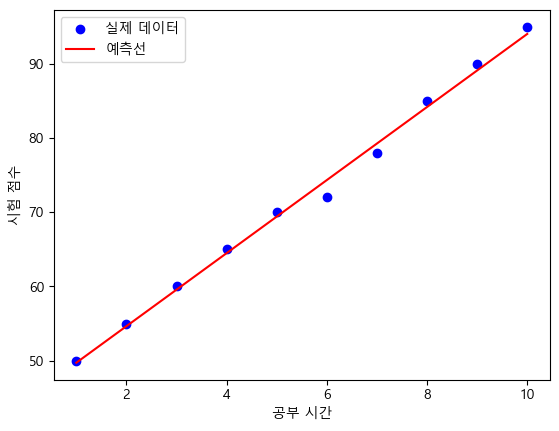

In [9]:
# 숫자를 예측하는 회귀(Regression)
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 데이터: [공부시간(시간)] → 시험점수
x = np.array([[1],[2],[3],[4],[5],[6],[7],[8],[9],[10]])
y = np.array([50, 55, 60, 65, 70, 72, 78, 85, 90, 95])

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(x_train, y_train)

y_pred = model.predict(x_test)

score = model.score(x_test, y_test)
print(f"모델 점수: {score:.3f}")

pred_11 = model.predict([[11]])
print(f"11시간 공부 시 예측 점수: {pred_11[0]:.1f}점")

# 시각화 (그냥 실행해보세요)
plt.scatter(x, y, color='blue', label='실제 데이터')
plt.plot(x, model.predict(x), color='red', label='예측선')
plt.xlabel('공부 시간')
plt.ylabel('시험 점수')
plt.legend()
plt.show()

In [16]:
# 카테고리를 분류하는 Classification
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

iris = load_iris()
x, y = iris.data, iris.target

print("x 형태:", x.shape)       # 몇 개의 샘플, 몇 개의 특징?
print("y 종류:", set(y))        # 몇 가지 꽃 종류?
print("특징 이름:", iris.feature_names)
print("꽃 종류:", iris.target_names)
print("첫 번째 샘플:", x[0])

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

model = DecisionTreeClassifier()
model.fit(x_train, y_train)

y_pred = model.predict(x_test)
print(f"\n정확도: {accuracy_score(y_test, y_pred):.3f}")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

train_score = model.score(x_train, y_train)
test_score = model.score(x_test, y_test)
print(f"학습 정확도: {train_score:.3f}")
print(f"테스트 정확도: {test_score:.3f}")

x 형태: (150, 4)
y 종류: {np.int64(0), np.int64(1), np.int64(2)}
특징 이름: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
꽃 종류: ['setosa' 'versicolor' 'virginica']
첫 번째 샘플: [5.1 3.5 1.4 0.2]

정확도: 1.000
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

학습 정확도: 1.000
테스트 정확도: 1.000


- precision - 정밀도 : 모델이 "이 꽃이다" 했을 때 실제로 맞은 비율
- recall - 재현율 : 실제 그 꽃을 모델이 찾아낸 비율
- f1-score - 두 지표의 균형 : precision + recall 종합 점수
- support : 테스트 샘플 수 : setosa 10개, versicolor 9개, virginica 11개

- 100%가 좋은것은 아님 -> 실제로 정확도가 너무 높으면 과적합(Overfitting)을 의심해야함

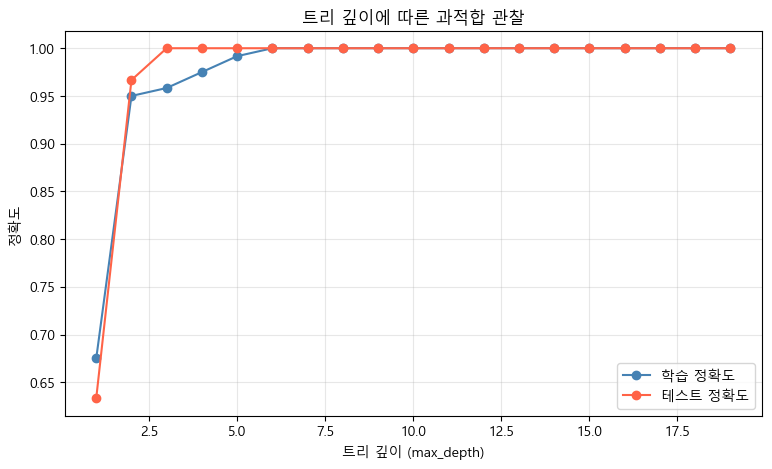

In [17]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

iris = load_iris()
X, y = iris.data, iris.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

train_scores = []
test_scores = []
depths = range(1, 20)

for depth in depths:
    model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    model.fit(X_train, y_train)
    train_scores.append(model.score(X_train, y_train))
    test_scores.append(model.score(X_test, y_test))

plt.figure(figsize=(9, 5))
plt.plot(depths, train_scores, 'o-', label='학습 정확도', color='steelblue')
plt.plot(depths, test_scores, 'o-', label='테스트 정확도', color='tomato')
plt.xlabel('트리 깊이 (max_depth)')
plt.ylabel('정확도')
plt.title('트리 깊이에 따른 과적합 관찰')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [19]:
# 결정트리 vs 랜덤 포레스트 직접 비교
from sklearn.datasets import make_classification
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

x, y = make_classification(
    n_samples=300,      # 데이터 개수 (행 수)
    n_features=10,      # feature(컬럼) 총 개수
    n_informative=5,    # 실제로 정답 예측에 중요한 feature 개수
    n_redundant=3,      # informative feature를 조합해서 만든 중복 feature 개수
    random_state=42     
)

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

dt = DecisionTreeClassifier(random_state=42)
dt.fit(x_train, y_train)
dt_train = dt.score(x_train, y_train)
dt_test = dt.score(x_test, y_test)
print(f"[결정트리] 학습: {dt_train:.3f} 테스트: {dt_test:.3f}")

# 트리 100개
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(x_train, y_train)
rf_train = rf.score(x_train, y_train)
rf_test = rf.score(x_test, y_test)
print(f"[랜덤포레스트] 학습: {rf_train:.3f} 테스트: {rf_test:.3f}")

importances = rf.feature_importances_   # 어떤 변수가 중요한지 파악
for i, imp in enumerate(importances):
    print(f" feature {i}: {imp:.3f}")



[결정트리] 학습: 1.000 테스트: 0.733
[랜덤포레스트] 학습: 1.000 테스트: 0.883
 feature 0: 0.093
 feature 1: 0.054
 feature 2: 0.190
 feature 3: 0.083
 feature 4: 0.155
 feature 5: 0.055
 feature 6: 0.084
 feature 7: 0.113
 feature 8: 0.135
 feature 9: 0.037


### SVM(Support Vector Machine)
- 두 그룹을 가장 넓게 갈라놓는 선(경계)을 찾는 것
- 마진(Margin)을 최대화 하는게 목표 -> 새로운 데이터가 들어와도 안정적 분류 가능

In [23]:
from sklearn.datasets import make_classification
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

x, y = make_classification(
    n_samples = 300, 
    n_features = 10,
    n_informative = 5,
    n_redundant = 3,
    random_state=42
)

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
                                                                                                                                                                                                                                                                                
# SVM은 스케일에 민감해서 반드시 정규화가 필요
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

svm = SVC(kernel='rbf', random_state=42)
svm.fit(x_train_scaled, y_train)
svm_train = svm.score(x_train_scaled, y_train)
svm_test = svm.score(x_test_scaled, y_test)
print(f"[SVM] 학습: {svm_train:.3f} 테스트: {svm_test:.3f}")

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(x_train_scaled, y_train)
rf_train = rf.score(x_train_scaled, y_train)
rf_test = rf.score(x_test_scaled, y_test)
print(f"[랜덤포레스트] 학습: {rf_train:.3f}  테스트: {rf_test:.3f}")

svm_no_scale = SVC(kernel='rbf', random_state=42)
svm_no_scale.fit(x_train, y_train)
print(f"[SVM 정규화 X] 테스트: {svm_no_scale.score(x_test, y_test):.3f}")

[SVM] 학습: 0.904 테스트: 0.933
[랜덤포레스트] 학습: 1.000  테스트: 0.883
[SVM 정규화 X] 테스트: 0.933


### KNN & 나이브 베이즈
#### KNN (K-Nearest Neighbors) - 가장 직관적인 모델
- 주변 K명을 보고 다수결로 결정

#### 나이브 베이즈(Naive-Bayes) - 확률로 분류
- 각 클래스일 확률을 계산해서 높은 쪽으로 분류
- 모든 feature가 서로 독립적이라고 순진하게 가정

In [28]:
# 4개 모델 한번에 비교
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

x, y = make_classification(
    n_samples = 300,
    n_features = 10,
    n_informative = 5,
    n_redundant = 3,
    random_state = 42
)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# 모델 4개를 딕셔너리로 한번에 관리
models = {
    'KNN (k=3)' : KNeighborsClassifier(n_neighbors=3),
    'KNN (k=10)' : KNeighborsClassifier(n_neighbors=10),
    'naive_bayes' : GaussianNB(),
    'SVM' : SVC(kernel='rbf', random_state=42),
    'random_forest' : RandomForestClassifier(n_estimators=100, random_state=42)
}

for name, model in models.items():
    model.fit(x_train_scaled, y_train)
    pred = model.predict(x_test)
    train_score = model.score(x_train_scaled, y_train)
    test_score = model.score(x_test_scaled, y_test)
    print((f"{name:15s} 학습: {train_score:.3f} 테스트: {test_score:.3f}"))

KNN (k=3)       학습: 0.908 테스트: 0.800
KNN (k=10)      학습: 0.863 테스트: 0.817
naive_bayes     학습: 0.817 테스트: 0.817
SVM             학습: 0.904 테스트: 0.933
random_forest   학습: 1.000 테스트: 0.883


### 비지도 학습
- 이전 x(입력) + y(정답) -> 모델 학습 -> 새 x로 예측
#### K-Means
- x(입력) -> 모델 스스로 그룹 발견 -> 정답 X 
- 정답 라벨 없이 "비슷한 것끼리 묶어라"만 시킴. 고객 세분화, 이상치 탐지, 유전자 분석 등에서 많이 씀
#### K-means 작동 원리
1. 랜덤하게 K개의 중심점 찍기
2. 모든 데이터를 가장 가까운 중심점에 배정
3. 각 그룹의 평균으로 중심점 이동
4. 중심점이 안 움직일 때까지 2~3 반복

그룹 번호 종류: {np.int32(0), np.int32(1), np.int32(2)}
중심점:
 [[-0.21277029  1.15926337]
 [-1.07970061 -1.25787405]
 [ 1.2924709   0.09861068]]


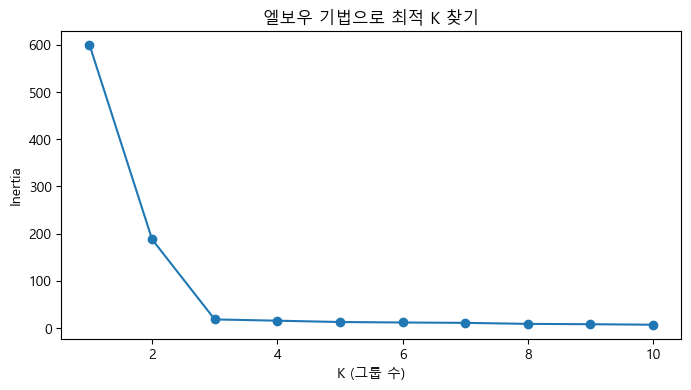


PCA 전: (300, 10)
PCA 후: (300, 2)
설명된 분산 비율: [0.43733998 0.17407099]
두 축이 설명하는 총 정보량: 61.1%


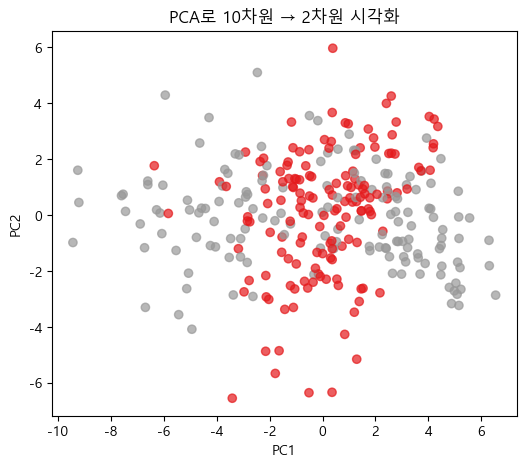

In [39]:
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np

# 3개 그룹 데이터 생성
x, y = make_blobs(
    n_samples=300, 
    centers=3, 
    cluster_std=1.0,
    random_state=42
    )
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

# K-Means로 3개 그룹으로 묶기
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(x_scaled)
labels = kmeans.labels_     # 각 데이터의 그룹 번호
centers = kmeans.cluster_centers_   # 중심점 좌표
print("그룹 번호 종류:", set(labels))
print("중심점:\n", centers)

# 최적의 K 찾기 (엘보우 기법)
inertias = []       # 클러스터링이 얼마나 잘 되었는지 나타내는 값
k_range = range(1, 11)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(x_scaled)
    inertias.append(km.inertia_)    # 각 점과 중심점의 거리 합

plt.figure(figsize=(8,4))
plt.plot(k_range, inertias, 'o-')
plt.xlabel('K (그룹 수)')
plt.ylabel('Inertia')
plt.title('엘보우 기법으로 최적 K 찾기')
plt.show()

# PCA로 고차원 데이터를 2D로 압축해서 시각화
# 10차원 데이터 생성
from sklearn.datasets import make_classification
x_high, y_high = make_classification(
    n_samples=300, n_features=10, n_informative=5, random_state=42)

pca = PCA(n_components=2)   # 10차원 -> 2차원
x_2d = pca.fit_transform(x_high)

print(f"\nPCA 전: {x_high.shape}")
print(f"PCA 후: {x_2d.shape}")
print(f"설명된 분산 비율: {pca.explained_variance_ratio_}") # 각 주성분(Principal Component)이 원본 데이터의 정보를 얼마나 잘 설명하는가
print(f"두 축이 설명하는 총 정보량: {sum(pca.explained_variance_ratio_):.1%}")

plt.figure(figsize=(6, 5))
plt.scatter(x_2d[:, 0], x_2d[:, 1], c=y_high, cmap='Set1', alpha=0.7)
plt.title('PCA로 10차원 → 2차원 시각화')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

### 교차검증 & 하이퍼파라미터 튜닝
- K-Fold 교차검증
- 데이터를 5등분  
1회: [검증] [학습] [학습] [학습] [학습] → 점수1  
2회: [학습] [검증] [학습] [학습] [학습] → 점수2  
3회: [학습] [학습] [검증] [학습] [학습] → 점수3  
4회: [학습] [학습] [학습] [검증] [학습] → 점수4  
5회: [학습] [학습] [학습] [학습] [검증] → 점수5  

In [47]:
# 교차검증 + Grid Search
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
import numpy as np

x, y = make_classification(
    n_samples = 300,
    n_features = 10,
    n_informative = 5,
    n_redundant = 3,
    random_state = 42
)

scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

# 교차검증으로 SVM 점수 측정 (5-fold)
scores = cross_val_score(SVC(kernel='rbf'), x_scaled, y, cv=5)
print(f"각 fold 점수: {scores}")
print(f"평균: {scores.mean():.3f} (+/- {scores.std():.3f})")

# Grid Search로 최적 하이퍼파라미터 찾기
# C : 마진 얼마나 엄격하게, gamma: 결정 경계 복잡도
param_grid = {
    'C' : [0.1, 1, 3, 10, 100],
    'gamma' : [0.001, 0.01, 0.1, 1]
}
grid_search = GridSearchCV(
    SVC(kernel='rbf'),
    param_grid,
    cv=5,
    scoring='accuracy'
)
grid_search.fit(x_scaled, y)

print(f"\n최적 파라미터: {grid_search.best_params_}")
print(f"최적 점수:     {grid_search.best_score_:.3f}")

# 기본값 SVM vs 최적 SVM 비교
svm_default = cross_val_score(SVC(kernel='rbf'), x_scaled, y, cv=5).mean()
svm_tuned = grid_search.best_score_
print(f"\n기본 SVM:  {svm_default:.3f}")
print(f"튜닝 SVM:  {svm_tuned:.3f}")
print(f"향상폭:    +{svm_tuned - svm_default:.3f}")


각 fold 점수: [0.85       0.9        0.9        0.78333333 0.78333333]
평균: 0.843 (+/- 0.052)

최적 파라미터: {'C': 3, 'gamma': 0.1}
최적 점수:     0.860

기본 SVM:  0.843
튜닝 SVM:  0.860
향상폭:    +0.017


### XGBoost + 불균형 데이터
- 실수를 반복하지 않도록 계속 보완하는 방식 : 부스팅(Boosting)  
트리 1 학습 → 틀린 것 분석  
트리 2: 트리 1이 틀린 부분에 집중해서 학습  
트리 3: 트리 2가 틀린 부분에 집중해서 학습  
...  
최종: 모든 트리 예측을 합산  

- 불균형 데이터  
    - 정상 거래: 9,900건 (99%)  
    - 사기 거래:   100건  (1%)  
    이런 데이터에서는 전부 정상이라고만 해도 정확도 99%

In [55]:
from sklearn.datasets import make_classification
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from xgboost import XGBClassifier
import numpy as np

# 불균형 데이터 생성 (95% vs 5%)
x , y = make_classification(
    n_samples=1000, n_features=10,
    n_informative=5, n_redundant=3,
    weights=[0.95, 0.05],
    random_state=42
)
print(f"클래스 분포: 정상 {sum(y==0)}개, 이상 {sum(y==1)}개")

# 랜덤포레스트 교차검증 (정확도 vs f1비교)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_acc = cross_val_score(rf, x, y, cv=5, scoring='accuracy').mean()
rf_f1 = cross_val_score(rf, x, y, cv=5, scoring='f1').mean()
print(f"\n[랜덤포레스트]")
print(f"  정확도: {rf_acc:.3f}")
print(f"  F1:     {rf_f1:.3f}")

# XGBoost (scale_pos_weight로 불균형 처리)
ratio = sum(y==0) / sum(y==1)   # 다수 클래스 / 소수 클래스
xgb = XGBClassifier(
    scale_pos_weight = ratio,
    eval_metric='logloss',
    random_state=42
)
xgb_acc = cross_val_score(xgb, x, y, cv=5, scoring='accuracy').mean()
xgb_f1 = cross_val_score(xgb, x, y, cv=5, scoring='f1').mean()
print(f"\n[XGBoost]")
print(f"  정확도: {xgb_acc:.3f}")
print(f"  F1:     {xgb_f1:.3f}")

# confusion matrix로 실제 사기를 얼마나 잡는지 확인
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

xgb.fit(x_train, y_train)
y_pred = xgb.predict(x_test)

print("\n[Confusion Matrix]")
print(confusion_matrix(y_test, y_pred))
print("\n[Classification Report]")
print(classification_report(y_test, y_pred))

클래스 분포: 정상 945개, 이상 55개

[랜덤포레스트]
  정확도: 0.970
  F1:     0.628

[XGBoost]
  정확도: 0.969
  F1:     0.684

[Confusion Matrix]
[[185   4]
 [  3   8]]

[Classification Report]
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       189
           1       0.67      0.73      0.70        11

    accuracy                           0.96       200
   macro avg       0.83      0.85      0.84       200
weighted avg       0.97      0.96      0.97       200

